In [1]:
# código para instalação dos pacotes necessários
install.packages(c("rstatix", "rnaturalearth", "viridis", "rnaturalearthdata", "gridExtra"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘proxy’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘RcppEigen’, ‘e1071’, ‘wk’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘classInt’, ‘s2’, ‘units’, ‘corrplot’, ‘car’, ‘sf’, ‘terra’




In [2]:
# código para carregar pacotes necessários
library(readr)
library(tidyverse)
library(rstatix)
library(rnaturalearth)
library(viridis)
library(rnaturalearthdata)
library(gridExtra)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.0.2
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter


Loading required package: viridisLite


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [3]:
# código para leitura da base de dados "tidy_data.csv"
tidy_data <- read_csv2("/content/tidy_data.csv")

ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

New names:
• `` -> `...1`
Rows: 17489 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ";"
chr  (2): indicator, code
dbl (13): ...1, estimate, stddev, nsource, pctrank, pctranklower, pctrankupp...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
# código para exibir a estrutura do banco de dados "tidy_data"
str(tidy_data)

spc_tbl_ [17,489 × 15] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ ...1         : num [1:17489] 1 2 3 4 5 6 7 8 9 10 ...
 $ indicator    : chr [1:17489] "cc" "cc" "cc" "cc" ...
 $ code         : chr [1:17489] "AGO" "AGO" "AGO" "AGO" ...
 $ estimate     : num [1:17489] -0.0127 -0.0171 0.042 -0.18 -0.0421 ...
 $ stddev       : num [1:17489] -0.03502 0.02313 -0.03785 -0.02185 -0.00585 ...
 $ nsource      : num [1:17489] 4 4 4 6 8 8 10 9 10 11 ...
 $ pctrank      : num [1:17489] -2.191 1.024 -0.574 -2.646 0.62 ...
 $ pctranklower : num [1:17489] -0.538 0 0 0 0 ...
 $ pctrankupper : num [1:17489] -0.147 0.387 -1.734 -14.286 1.66 ...
 $ eiu          : num [1:17489] 0 0 0 0 0 0 0 0 0 0 ...
 $ prs          : num [1:17489] -0.167 0 0 0 0 ...
 $ wmo          : num [1:17489] 0 0 0 0 0.125 -0.125 0 0 0.0625 0 ...
 $ scalemean    : num [1:17489] 0.00661 0.00462 -0.00782 -0.03561 -0.01796 ...
 $ scalesd      : num [1:17489] 0.942 0.932 0.934 0.929 0.923 ...
 $ extreme_event: num [1:17489] 0 0 0 0 0 0

In [5]:
# código para converter "tidy_data" em dataframe
tidy_data <- as.data.frame(tidy_data)

# código para ver as primeiras linhas do banco de dados "tidy_data"
head(tidy_data, n = 3)

,...1,indicator,code,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper,eiu,prs,wmo,scalemean,scalesd,extreme_event
,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,cc,AGO,-0.01274884,-0.03502110,4,-2.1907887,-0.5376344,-0.1466274,0,-0.1666667,0,0.006609586,0.9419084,0
2,2,cc,AGO,-0.01706362,0.02312991,4,1.0240073,0.0000000,0.3868465,0,0.0000000,0,0.004617358,0.9321700,0
3,3,cc,AGO,0.04202163,-0.03785276,4,-0.5741305,0.0000000,-1.7336483,0,0.0000000,0,-0.007820761,0.9338263,0


In [6]:
# código para gerar um resumo estatístico básico do banco de dados "tidy_data"
summary(tidy_data)

      ...1        indicator             code              estimate        
 Min.   :    1   Length:17489       Length:17489       Min.   :-3.180352  
 1st Qu.: 4373   Class :character   Class :character   1st Qu.:-0.489193  
 Median : 8745   Mode  :character   Mode  :character   Median :-0.019867  
 Mean   : 8745                                         Mean   : 0.002793  
 3rd Qu.:13117                                         3rd Qu.: 0.377950  
 Max.   :17489                                         Max.   : 2.469660  
     stddev             nsource          pctrank         pctranklower   
 Min.   :-0.117370   Min.   : 3.000   Min.   :-38.699   Min.   :-35.38  
 1st Qu.:-0.004432   1st Qu.: 7.000   1st Qu.:  2.335   1st Qu.:  1.07  
 Median : 0.002699   Median : 9.000   Median : 29.187   Median : 16.22  
 Mean   : 0.053012   Mean   : 9.142   Mean   : 35.144   Mean   : 27.73  
 3rd Qu.: 0.145183   3rd Qu.:11.000   3rd Qu.: 62.857   3rd Qu.: 53.05  
 Max.   : 0.344504   Max.   :20.000  

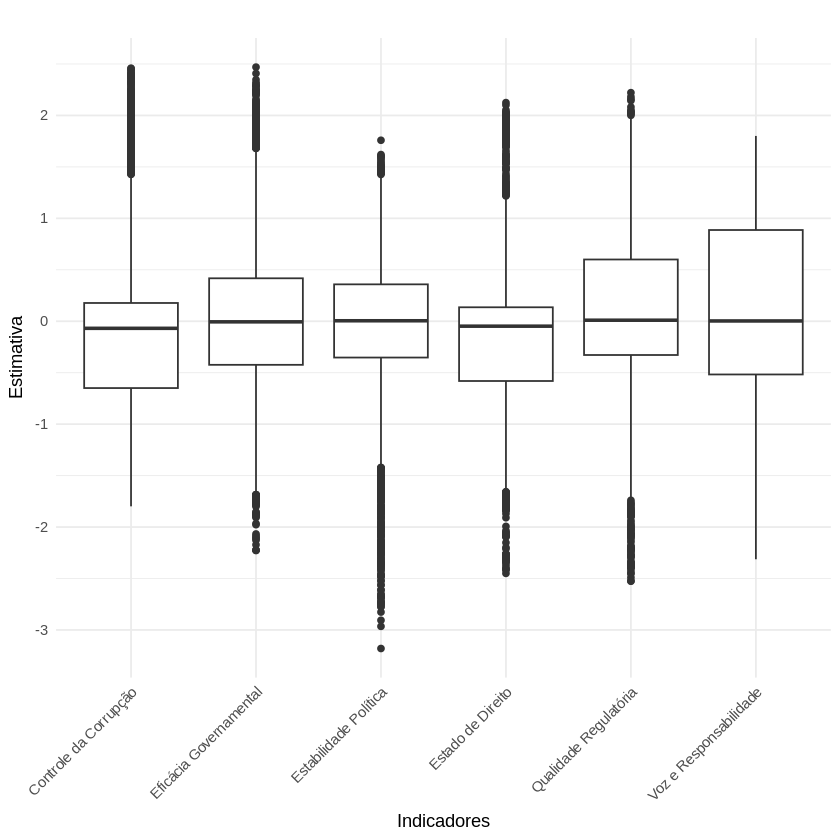

In [7]:
# código para gerar boxplot dos indicadores
ggplot(tidy_data, aes(x = indicator, y = estimate)) +
  geom_boxplot() +
  labs(title = "", x = "Indicadores", y = "Estimativa") +
  scale_x_discrete(labels = c("pv" = "Estabilidade Política",
                              "ge" = "Eficácia Governamental",
                              "rl" = "Estado de Direito",
                              "rq" = "Qualidade Regulatória",
                              "va" = "Voz e Responsabilidade",
                              "cc" = "Controle da Corrupção")) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [8]:
# Desenvolvimento da Análise Estatística

#  Teste de Kruskall-Wallis
# H0: não existe diferença significativa entre os grupos
# Ha: pelo menos um dos grupos difere significativamente dos demais

# código para aplicar o teste de Kruskal-Wallis
kruskal_result <- kruskal.test(estimate ~ indicator, data = tidy_data)
kruskal_result


	Kruskal-Wallis rank sum test

data:  estimate by indicator
Kruskal-Wallis chi-squared = 184.29, df = 5, p-value < 2.2e-16


In [9]:
# código para aplicar o teste de Dunn
dunn_resultados <- dunn_test(estimate ~ indicator, data = tidy_data, p.adjust.method = "bonferroni")
View(dunn_resultados)

,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,estimate,cc,ge,3130,3142,8.20517034,2.302642e-16,3.453963e-15,****
2,estimate,cc,pv,3130,3128,6.40148250,1.538755e-10,2.308132e-09,****
3,estimate,cc,rl,3130,3138,-0.01781209,9.857888e-01,1.000000e+00,ns
4,estimate,cc,rq,3130,3139,9.87393517,5.400346e-23,8.100519e-22,****
5,estimate,cc,va,3130,1812,7.09571923,1.286805e-12,1.930207e-11,****
6,estimate,ge,pv,3142,3128,-1.79625510,7.245396e-02,1.000000e+00,ns
7,estimate,ge,rl,3142,3138,-8.22824407,1.899777e-16,2.849665e-15,****
8,estimate,ge,rq,3142,3139,1.67232063,9.446111e-02,1.000000e+00,ns
9,estimate,ge,va,3142,1812,0.07612572,9.393191e-01,1.000000e+00,ns


In [10]:
# código para plotar o gráfico de densidade de cada par de indicadores
par_indicador <- tidy_data[tidy_data$indicator %in% c('cc', 'ge'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador, FUN = median)
g1 <- ggplot(par_indicador, aes(x = estimate, color = indicator)) +
  geom_density(alpha = 0.5) +
  theme_classic() +
  labs(title = "a) cc e ge",
       x = "",
       y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador2 <- tidy_data[tidy_data$indicator %in% c('cc', 'pv'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador2, FUN = median)
g2 <- ggplot(par_indicador2, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "b) cc e pv", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador3 <- tidy_data[tidy_data$indicator %in% c('cc', 'rl'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador3, FUN = median)
g3 <- ggplot(par_indicador3, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "c) cc e rl", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador4 <- tidy_data[tidy_data$indicator %in% c('cc', 'rq'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador4, FUN = median)
g4 <- ggplot(par_indicador4, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "d) cc e rq", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador5 <- tidy_data[tidy_data$indicator %in% c('cc', 'va'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador5, FUN = median)
g5 <- ggplot(par_indicador5, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "e) cc e va", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador6 <- tidy_data[tidy_data$indicator %in% c('ge', 'pv'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador6, FUN = median)
g6 <- ggplot(par_indicador6, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "f) ge e pv", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador7 <- tidy_data[tidy_data$indicator %in% c('ge', 'rl'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador7, FUN = median)
g7 <- ggplot(par_indicador7, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "g) ge e rl", x = "", y = "Densidade") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador8 <- tidy_data[tidy_data$indicator %in% c('ge', 'rq'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador8, FUN = median)
g8 <- ggplot(par_indicador8, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "h) ge e rq", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador9 <- tidy_data[tidy_data$indicator %in% c('ge', 'va'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador9, FUN = median)
g9 <- ggplot(par_indicador9, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "i) ge e va", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador10 <- tidy_data[tidy_data$indicator %in% c('pv', 'rl'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador10, FUN = median)
g10 <- ggplot(par_indicador10, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "j) pv e rl", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador11 <- tidy_data[tidy_data$indicator %in% c('pv', 'rq'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador11, FUN = median)
g11 <- ggplot(par_indicador11, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "k) pv e rq", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador12 <- tidy_data[tidy_data$indicator %in% c('pv', 'va'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador12, FUN = median)
g12 <- ggplot(par_indicador12, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "l) pv e va", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador13 <- tidy_data[tidy_data$indicator %in% c('rl', 'rq'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador13, FUN = median)
g13 <- ggplot(par_indicador13, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "m) rl e rq", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador14 <- tidy_data[tidy_data$indicator %in% c('rl', 'va'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador14, FUN = median)
g14 <- ggplot(par_indicador14, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "n) rl e va", x = "Estimativa", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed") +
  theme(legend.position = "none")

par_indicador15 <- tidy_data[tidy_data$indicator %in% c('rq', 'va'), ]
medianas <- aggregate(estimate ~ indicator, data = par_indicador15, FUN = median)
g15 <- ggplot(par_indicador15, aes(x = estimate, color = indicator)) + geom_density(alpha = 0.5) + theme_classic() +
  labs(title = "o) rq e va", x = "", y = "") +
  geom_vline(data = medianas, aes(xintercept = estimate, color = indicator),
             linetype = "dashed")  +
  theme(legend.position = "none")

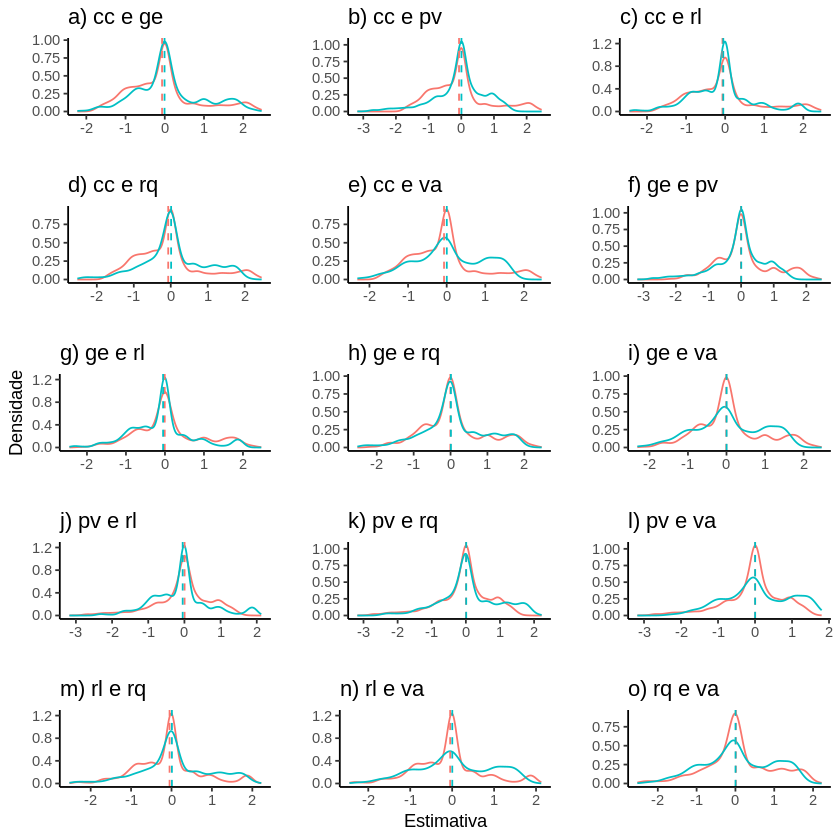

In [11]:
# código para exibir os gráficos de densidade em conjunto
grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10, g11, g12, g13, g14, g15, ncol = 3)

In [12]:
# Desenvolvimento do Mapa de Calor

# código para selecionar as variáveis de interesse
dados_mapa <- tidy_data %>%
  dplyr::select(indicator, code, estimate)

In [13]:
# código para carregar o banco de dados geométricos
data_world <- ne_countries(scale = "medium", returnclass = "sf")

In [14]:
# código para listar o código (tidy_data) e o nome (data_world) dos países
lista_paises <- data.frame(
  code = c("AFG", "ALB", "DZA", "ADO", "AGO", "ATG", "ARG", "ARM", "AUS", "AUT", "AZE", "BHR", "BGD", "BRB", "BLR", "BEL", "BLZ", "BEN", "BTN", "BOL", "BIH", "BWA", "BRA", "BRN", "BGR", "BFA", "BDI", "CPV", "KHM", "CMR", "CAN", "CAF", "TCD", "CHL", "CHN", "COL", "COM", "CRI", "HRV", "CUB", "CYP", "CZE", "ZAR", "DNK", "DJI", "DMA", "DOM", "TMP", "ECU", "EGY", "SLV", "GNQ", "ERI", "EST", "SWZ", "ETH", "FSM", "FJI", "FIN", "FRA", "GAB", "GMB", "GEO", "DEU", "GHA", "GRC", "GRD", "GTM", "GIN", "GNB", "GUY", "HTI", "HND", "HUN", "ISL", "IND", "IDN", "IRN", "IRQ", "IRL", "ISR", "ITA", "CIV", "JAM", "JPN", "JOR", "KAZ", "KEN", "KIR", "KSV", "KWT", "KGZ", "LAO", "LVA", "LBN", "LSO", "LBR", "LBY", "LIE", "LTU", "LUX", "MDG", "MWI", "MYS", "MDV", "MLI", "MLT", "MHL", "MRT", "MUS", "MEX", "MDA", "MCO", "MNG", "MNE", "MAR", "MOZ", "MMR", "NAM", "NRU", "NPL", "NLD", "NZL", "NIC", "NER", "NGA", "PRK", "MKD", "NOR", "OMN", "PAK", "PLW", "PAN", "PNG", "PRY", "PER", "PHL", "POL", "PRT", "QAT", "SRB", "COG", "ROM", "RUS", "RWA", "KNA", "LCA", "VCT", "WSM", "SMR", "STP", "SAU", "SEN", "SYC", "SLE", "SGP", "SVK", "SVN", "SLB", "SOM", "ZAF", "KOR", "SSD", "ESP", "LKA", "SDN", "SUR", "SWE", "CHE", "SYR", "TWN", "TJK", "THA", "BHS", "TGO", "TON", "TTO", "TUN", "TUR", "TKM", "TUV", "UGA", "UKR", "ARE", "GBR", "TZA", "USA", "URY", "UZB", "VUT", "VEN", "VNM", "YEM", "ZMB", "ZWE", "MKD"),
  sovereignt = c("Afghanistan", "Albania", "Algeria", "Andorra", "Angola", "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan", "Bahrain", "Bangladesh", "Barbados", "Belarus", "Belgium", "Belize", "Benin", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil", "Brunei", "Bulgaria", "Burkina Faso", "Burundi", "Cabo Verde", "Cambodia", "Cameroon", "Canada", "Central African Republic", "Chad", "Chile", "China", "Colombia", "Comoros", "Costa Rica", "Croatia", "Cuba", "Cyprus", "Czechia", "Democratic Republic of the Congo", "Denmark", "Djibouti", "Dominica", "Dominican Republic", "East Timor", "Ecuador", "Egypt", "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia", "eSwatini", "Ethiopia", "Federated States of Micronesia", "Fiji", "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada", "Guatemala", "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hungary", "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy", "Ivory Coast", "Jamaica", "Japan", "Jordan", "Kazakhstan", "Kenya", "Kiribati", "Kosovo", "Kuwait", "Kyrgyzstan", "Laos", "Latvia",
  "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein", "Lithuania", "Luxembourg", "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands", "Mauritania", "Mauritius",
  "Mexico", "Moldova", "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar", "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger", "Nigeria", "North Korea", "Northern Cyprus", "Norway", "Oman", "Pakistan", "Palau", "Panama", "Papua New Guinea", "Paraguay", "Peru", "Philippines", "Poland",
  "Portugal", "Qatar", "Republic of Serbia", "Republic of the Congo", "Romania", "Russia", "Rwanda", "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines", "Samoa", "San Marino", "São Tomé and Principe", "Saudi Arabia", "Senegal", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia", "Solomon Islands",
  "Somalia", "South Africa", "South Korea", "South Sudan", "Spain", "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria", "Taiwan", "Tajikistan", "Thailand", "The Bahamas", "Togo", "Tonga", "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu", "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom", "United Republic of Tanzania", "United States of America", "Uruguay", "Uzbekistan", "Vanuatu", "Venezuela", "Vietnam", "Yemen", "Zambia", "Zimbabwe", "North Macedonia")
)

In [15]:
# código para unir a lista de paises e o dados_mapa
data_mapa <- merge(dados_mapa, lista_paises, by = "code", all.x = TRUE)

In [16]:
# código para aplicar a médias dos estimadores de cada indicador
resumo_mapa <- data_mapa %>%
  group_by(indicator, sovereignt) %>%
  summarize(media_estimate = mean(estimate, na.rm = TRUE))

`summarise()` has grouped output by 'indicator'. You can override using the
`.groups` argument.


In [17]:
# código para filtrar os bancos de dados pelos indicadores e selecionar as variáveis de interesse
dados_mapa_cc <- resumo_mapa %>%
  filter(indicator == "cc") %>%
  dplyr::select(indicator, sovereignt, media_estimate)

dados_mapa_pv <- resumo_mapa %>%
  filter(indicator == "pv") %>%
  dplyr::select(indicator, sovereignt, media_estimate)

dados_mapa_rl <- resumo_mapa %>%
  filter(indicator == "rl") %>%
  dplyr::select(indicator, sovereignt, media_estimate)

dados_mapa_rq <- resumo_mapa %>%
  filter(indicator == "rq") %>%
  dplyr::select(indicator, sovereignt, media_estimate)

dados_mapa_va <- resumo_mapa %>%
  filter(indicator == "va") %>%
  dplyr::select(indicator, sovereignt, media_estimate)

dados_mapa_ge <- resumo_mapa %>%
  filter(indicator == "ge") %>%
  dplyr::select(indicator, sovereignt, media_estimate)

In [18]:
# código para renomear a coluna media_estimate pelo nome do indicador
dados_mapa_cc <- dados_mapa_cc %>%
  rename(cc = media_estimate)

dados_mapa_ge <- dados_mapa_ge %>%
  rename(ge = media_estimate)

dados_mapa_rl <- dados_mapa_rl %>%
  rename(rl = media_estimate)

dados_mapa_rq <- dados_mapa_rq %>%
  rename(rq = media_estimate)

dados_mapa_va <- dados_mapa_va %>%
  rename(va = media_estimate)

dados_mapa_pv <- dados_mapa_pv %>%
  rename(pv = media_estimate)

In [19]:
# código para unir a base de dados geométrica com a media dos indicador "va"
dados_prontos <- data_world %>%
  left_join(dados_mapa_va, by = "sovereignt")

# código para plotar o gráfico do indicador "va"
graf_calor_va <- ggplot(dados_prontos) +
  geom_sf(aes(fill = va), color = "white", size = 0.2) +
  scale_fill_viridis_c(option = "C", na.value = "gray") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(0, 0, 0, 0)
  ) +
  labs(
    title = "Voz e Responsabilidade",
    fill = ""
  ) +
  theme(legend.position = "bottom")

In [20]:
# código para unir a base de dados geométrica com a media dos indicador "cc"
dados_prontos <- data_world %>%
  left_join(dados_mapa_cc, by = "sovereignt")

# código para plotar o gráfico do indicador "va"
graf_calor_cc <- ggplot(dados_prontos) +
  geom_sf(aes(fill = cc), color = "white", size = 0.2) +
  scale_fill_viridis_c(option = "C", na.value = "gray") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(0, 0, 0, 0)
  ) +
  labs(
    title = "Controle da Corrupção",
    fill = ""
  ) +
  theme(legend.position = "bottom")

In [21]:
# código para unir a base de dados geométrica com a media dos indicador "ge"
dados_prontos <- data_world %>%
  left_join(dados_mapa_ge, by = "sovereignt")

# código para plotar o gráfico do indicador "ge"
graf_calor_ge <- ggplot(dados_prontos) +
  geom_sf(aes(fill = ge), color = "white", size = 0.2) +
  scale_fill_viridis_c(option = "C", na.value = "gray") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(0, 0, 0, 0)
  ) +
  labs(
    title = "Eficácia Governamental",
    fill = ""
  ) +
  theme(legend.position = "bottom")

In [22]:
# código para unir a base de dados geométrica com a media dos indicador "pv"
dados_prontos <- data_world %>%
  left_join(dados_mapa_pv, by = "sovereignt")

# código para plotar o gráfico do indicador "pv"
graf_calor_pv <- ggplot(dados_prontos) +
  geom_sf(aes(fill = pv), color = "white", size = 0.2) +
  scale_fill_viridis_c(option = "C", na.value = "gray") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(0, 0, 0, 0)
  ) +
  labs(
    title = "Estabilidade Política",
    fill = ""
  ) +
  theme(legend.position = "bottom")

In [23]:
# código para unir a base de dados geométrica com a media dos indicador "rl"
dados_prontos <- data_world %>%
  left_join(dados_mapa_rl, by = "sovereignt")

# código para plotar o gráfico do indicador "rl"
graf_calor_rl <- ggplot(dados_prontos) +
  geom_sf(aes(fill = rl), color = "white", size = 0.2) +
  scale_fill_viridis_c(option = "C", na.value = "gray") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(0, 0, 0, 0)
  ) +
  labs(
    title = "Estado de Direito",
    fill = ""
  ) +
  theme(legend.position = "bottom")

In [24]:
# código para unir a base de dados geométrica com a media dos indicador "rq"
dados_prontos <- data_world %>%
  left_join(dados_mapa_rq, by = "sovereignt")

# código para plotar o gráfico do indicador "rq"
graf_calor_rq <- ggplot(dados_prontos) +
  geom_sf(aes(fill = rq), color = "white", size = 0.2) +
  scale_fill_viridis_c(option = "C", na.value = "gray") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(0, 0, 0, 0)
  ) +
  labs(
    title = "Qualidade Regulatória",
    fill = ""
  ) +
  theme(legend.position = "bottom")

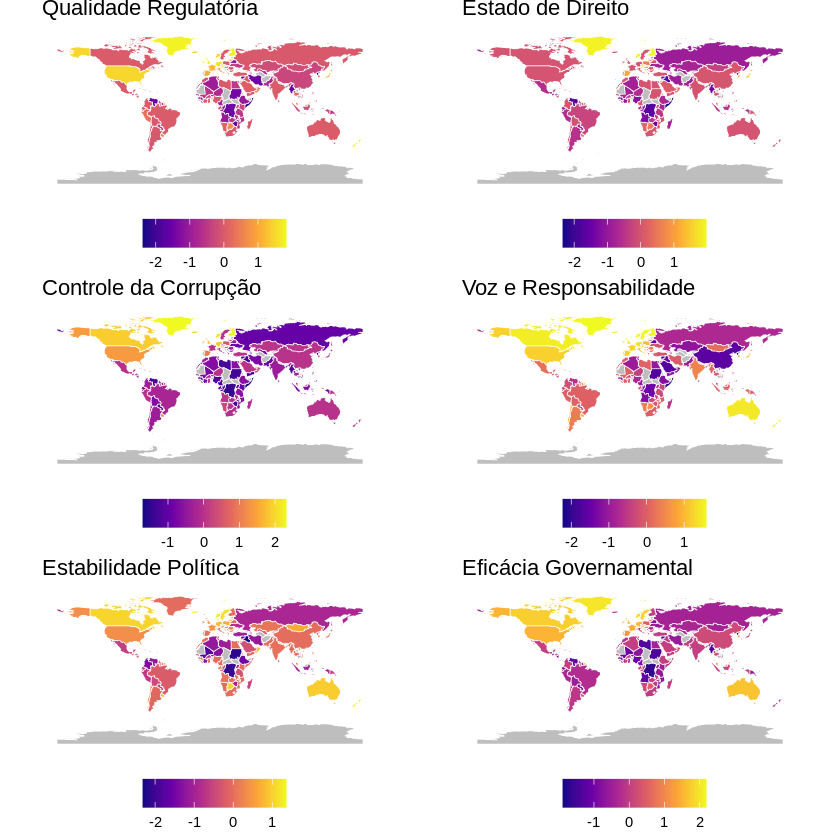

In [25]:
# código para exibir os mapas de calor em conjunto
grid.arrange(graf_calor_rq, graf_calor_rl, graf_calor_cc, graf_calor_va, graf_calor_pv, graf_calor_ge, ncol = 2)